In [1]:
print('hello')

hello


In [2]:
! pip install nltk

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# worldcloud
import random
from wordcloud import WordCloud


In [4]:
# Download NLTK resources (only needed once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to /Users/rania/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /Users/rania/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /Users/rania/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
# retrieving the datasets we used for the last notebook

raw_path = '../data/olist_datasets/'

df_customer = pd.read_csv(raw_path + 'olist_customers_dataset.csv')
df_geolocation = pd.read_csv(raw_path + 'olist_geolocation_dataset.csv')
df_orders = pd.read_csv(raw_path + 'olist_orders_dataset.csv')
df_order_items = pd.read_csv(raw_path + 'olist_order_items_dataset.csv')
df_order_payments = pd.read_csv(raw_path + 'olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv(raw_path + 'olist_order_reviews_dataset.csv')
df_products = pd.read_csv(raw_path + 'olist_products_dataset.csv')
df_sellers = pd.read_csv(raw_path + 'olist_sellers_dataset.csv')


# I - Sentiment analysis of customer reviews

## A - Reminders on the Review dataframe

In [6]:
# checking that df_order_reviews is loaded

df_order_reviews.head(10)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


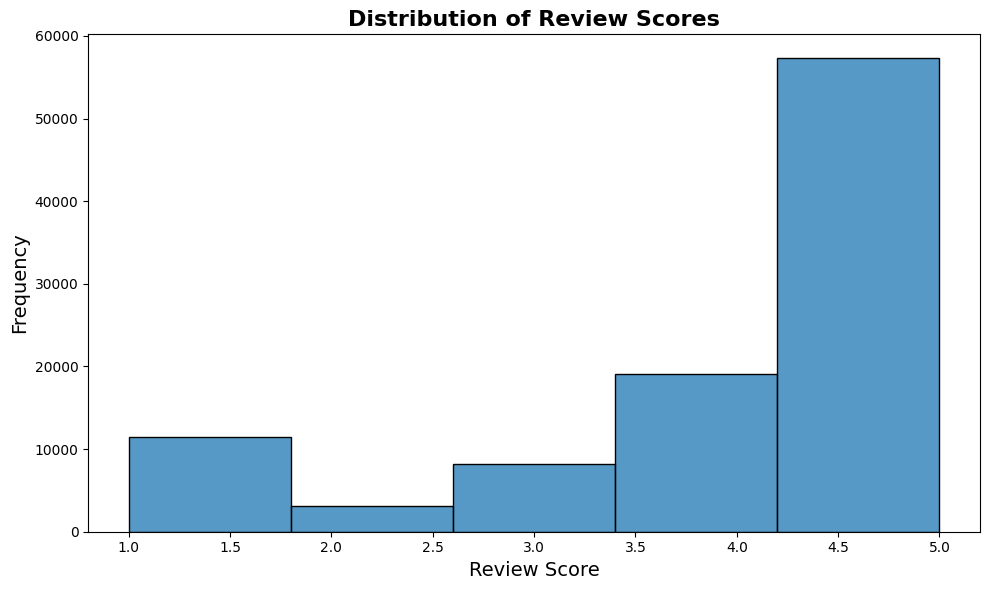

In [7]:
# Create a distribution plot (dist plot) with seaborn on the review score

# "professional" colors
colors = ['#2C3E50', '#E74C3C', '#ECF0F1', '#3498DB', '#2ECC71', '#F1C40F', '#9B59B6']

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram with seaborn
ax = sns.histplot(data=df_order_reviews, 
            x='review_score',
            bins=5,
            edgecolor='black',
            stat='count')

# Customizing the plot
plt.title('Distribution of Review Scores', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Ajuster les marges
plt.tight_layout()

# Show the plot
plt.show();


In [8]:
# Check for missing values in review comments
print(df_order_reviews['review_comment_message'].isnull().sum())

# Filter out rows with missing comments
df_order_reviews = df_order_reviews.dropna(subset=['review_comment_message'])


58247


In [9]:
# Create a new column to categorize reviews
def categorize_sentiment(score):
    if score >= 4:
        return 'good'
    elif score <= 2:
        return 'bad'
    else:
        return 'neutral'

# Apply the function to the dataframe
df_order_reviews['sentiment'] = df_order_reviews['review_score'].apply(categorize_sentiment)


/var/folders/1h/pcyg9d5941g2br5swywdh2g40000gn/T/ipykernel_11036/4083276058.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_order_reviews, x='sentiment', palette=['#2ECC71', '#E74C3C', '#F1C40F'])


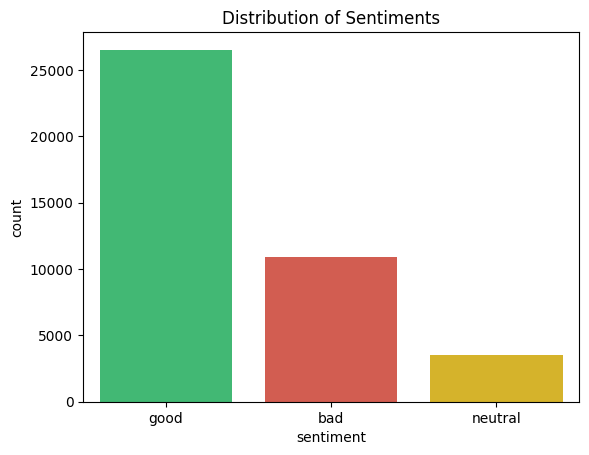

In [10]:
# Visualize the sentiment distribution - how many reviews by categories?

# Visualize the sentiment distribution
sns.countplot(data=df_order_reviews, x='sentiment', palette=['#2ECC71', '#E74C3C', '#F1C40F'])
plt.title('Distribution of Sentiments')
plt.show()


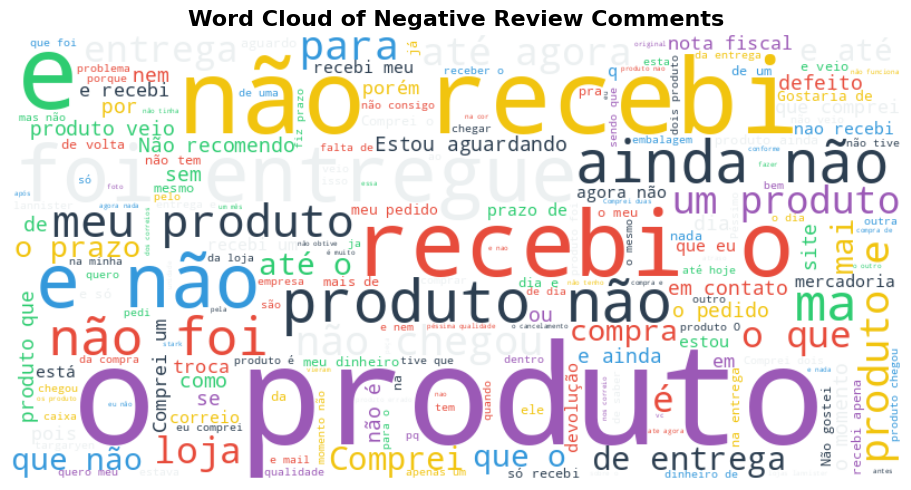

In [12]:
## Wordcloud

# Create a wordcloud on orders with negative reviews only

# On filtre les avis négatifs (score < 3) à partir de notre dataframe principal
reviews_with_negative_comments = df_order_reviews[df_order_reviews['review_score'] < 3]

# On génère le nuage de mots
wordcloud = WordCloud(width=800, height=400, background_color='white', color_func=color_func)
wordcloud.generate(' '.join(reviews_with_negative_comments['review_comment_message'].dropna()))

# Affichage
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Negative Review Comments', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## B - Text Preprocessing and conversion to numerical features

### 1 - Cleaning a small sample of the data and looking at the results

In [13]:
# create a new sample dataframe, that will be a sample of df_order_reviews
# which only have non null review_comment_messages
# which only contains review_id, review_score, review_comment_message

df_sample = df_order_reviews[['review_id', 'review_score', 'review_comment_message']].dropna().sample(1000, random_state=42)


In [14]:
# create a new comment_clean column which makes the text LOWER (no uppercases)

df_sample['comment_clean'] = df_sample['review_comment_message'].str.lower()


In [15]:
# remove the special characters using a simple regex function

import re

# On ne garde que les lettres et on enlève le reste
df_sample['comment_clean'] = df_sample['comment_clean'].apply(lambda x: re.sub(r'[^a-zA-Z\s]', '', str(x)))


In [16]:
# tokenize the text - meaning, isolate all words into a list, using the NLTK library, and another column - comment_clean_tokenized
from nltk.tokenize import word_tokenize

# On transforme la chaîne de caractères en liste de mots
df_sample['comment_clean'] = df_sample['comment_clean'].apply(word_tokenize)

# Affichage du résultat pour vérifier
df_sample[['review_comment_message', 'comment_clean']].head()

,review_comment_message,comment_clean
37062,Um produto como uma carteira somente poderia s...,"[um, produto, como, uma, carteira, somente, po..."
17697,"Entrega no prazo , bom produto .","[entrega, no, prazo, bom, produto]"
41606,entrega rápida,"[entrega, rpida]"
41683,Chegou no prazo e atendeu as minhas espectativas,"[chegou, no, prazo, e, atendeu, as, minhas, es..."
75879,Logística ótima entregue antes do prazo previs...,"[logstica, tima, entregue, antes, do, prazo, p..."


In [17]:
# then remove the stopwords using the portuguese library from NLTK

# Remove stopwords (Portuguese)
stop_words = set(stopwords.words('portuguese'))
df_sample['comment_clean'] = df_sample['comment_clean'].apply(lambda x: [w for w in x if w not in stop_words])

# Stemming
from nltk.stem import SnowballStemmer
stemmer = SnowballStemmer('portuguese') # Plus efficace pour le portugais que PorterStemmer
df_sample['comment_clean'] = df_sample['comment_clean'].apply(lambda x: [stemmer.stem(w) for w in x])


In [ ]:
# Use stemming to shorten the words as much as possible using another column - comment_clean_stemmed

stemmer = PorterStemmer()

'your code'


### 2 - Text preprocessing

In [18]:
def preprocess_text(text):
    if isinstance(text, str):
        # 1. Convert to lowercase
        text = text.lower()
        # 2. Remove special characters, numbers, and punctuation
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        # 3. Tokenize the text
        tokens = word_tokenize(text)
        # 4. Remove stopwords (Portuguese)
        stop_words = set(stopwords.words('portuguese'))
        tokens = [w for w in tokens if w not in stop_words]
        # 5. Stemming
        stemmer = SnowballStemmer('portuguese')
        tokens = [stemmer.stem(w) for w in tokens]
        # 6. Join tokens back into a string
        return " ".join(tokens)
    else:
        return ""

In [20]:
# Apply preprocessing to the review comments

# Apply preprocessing 
df_order_reviews['review_comment_cleaned'] = df_order_reviews['review_comment_message'].apply(preprocess_text)



In [21]:
# Display a sample of original and processed comments

df_order_reviews[['review_comment_message', 'review_comment_cleaned']].head(10)


,review_comment_message,review_comment_cleaned
3,Recebi bem antes do prazo estipulado.,receb bem antes praz estipul
4,Parabéns lojas lannister adorei comprar pela I...,parabns loj lannist ador compr internet segur ...
9,aparelho eficiente. no site a marca do aparelh...,aparelh eficient sit marc aparelh impress desi...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouc travandopel valor ta boa
15,"Vendedor confiável, produto ok e entrega antes...",vendedor confivel produt ok entreg antes praz
16,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",gost sab sempr receb compr agor decpcion
19,Péssimo,pssim
22,Loja nota 10,loj not
24,obrigado pela atençao amim dispensada,obrig atena amim dispens
27,A compra foi realizada facilmente.\r\nA entreg...,compr realiz facil entreg efetu antes praz dad...


### 3 - Final preparation steps

In [22]:
# Split the data into training and testing sets

# 1. On définit nos variables X (le texte nettoyé) et y (la cible/sentiment)
X = df_order_reviews['review_comment_cleaned']
y = df_order_reviews['sentiment']

# 2. On divise : 80% pour l'entraînement, 20% pour le test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# On vérifie la taille des groupes
print(f"Entraînement : {X_train.shape[0]} commentaires")
print(f"Test : {X_test.shape[0]} commentaires")

Entraînement : 32781 commentaires
Test : 8196 commentaires


## C - Building a Simple Naive Bayes Model

In [23]:
# Use CountVectorizer to convert text to a matrix of token counts
count_vectorizer = CountVectorizer(max_features=5000)  # Limit to top 5000 features

# On apprend le vocabulaire sur le groupe d'entraînement et on transforme
X_train_counts = count_vectorizer.fit_transform(X_train)

# On transforme le groupe de test (SANS réapprendre le vocabulaire)
X_test_counts = count_vectorizer.transform(X_test)

print(f"Shape of training features: {X_train_counts.shape}")
print(f"Shape of testing features: {X_test_counts.shape}")


Shape of training features: (32781, 5000)
Shape of testing features: (8196, 5000)


In [24]:
# understanding what we just did

# Some computation to find an interesting extract to look at
word_freq = X_train_counts.sum(axis=0).A1  # converting the matrix into an A1 array
word_indices = word_freq.argsort()[-10:][::-1]  # 10 most frequent words
top_feature_names = [count_vectorizer.get_feature_names_out()[i] for i in word_indices]

# creating a sample with 10 most frequent words + 5 first reviews
df_sample = pd.DataFrame(
    X_train_counts[:5, word_indices].toarray(),
    columns=top_feature_names
)

print("Displaying an extract of the bag-of-words matrix (5 first comments, 10 most frequent words):")
df_sample

Displaying an extract of the bag-of-words matrix (5 first comments, 10 most frequent words):


,produt,entreg,praz,compr,cheg,receb,antes,bom,recom,vei
0,0,1,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0
2,1,1,1,0,0,0,1,0,0,0
3,1,0,1,0,1,0,1,0,0,0
4,1,1,1,0,1,1,1,0,0,0


In [25]:
# Train a Naive Bayes classifier
nb_classifier = MultinomialNB()

nb_classifier.fit(X_train_counts, y_train)


MultinomialNB()

In [26]:
# Make predictions on the test set

y_pred = nb_classifier.predict(X_test_counts)

In [ ]:
# Evaluate the model

'your code'


In [27]:
# Display classification report
print("Classification Report:\n")

# Evaluate the model - Accuracy Score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Classification Report:

Accuracy: 0.81


              precision    recall  f1-score   support

         bad       0.74      0.79      0.77      2151
        good       0.89      0.91      0.90      5315
     neutral       0.29      0.18      0.22       730

    accuracy                           0.81      8196
   macro avg       0.64      0.63      0.63      8196
weighted avg       0.80      0.81      0.80      8196



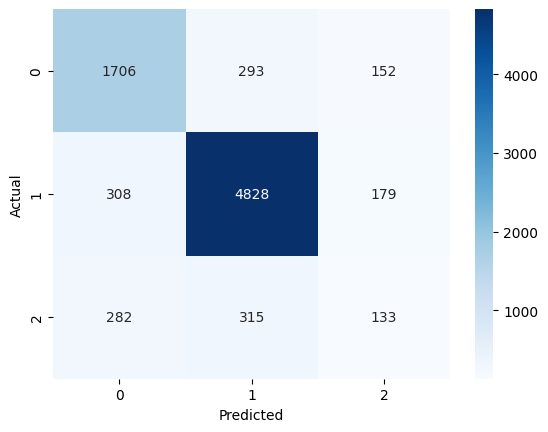

In [28]:
# Create and display confusion matrix

# Display classification report
print(classification_report(y_test, y_pred))

#  Confusion Matrix pour voir les erreurs
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## D - Building a More Advanced Model - Logistic Regression with TF-IDF

In [29]:
# Use TF-IDF Vectorizer for better feature extraction
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# On transforme le texte en nombres avec TF-IDF
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


In [30]:
# Train a Logistic Regression classifier
lr_classifier = LogisticRegression(max_iter=1000, random_state=42)

# Entraînement du modèle
lr_classifier.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [31]:
# Make predictions on the test set
# Prédictions
y_pred_lr = lr_classifier.predict(X_test_tfidf)

# Évaluation simple
print(f"Accuracy Logistic Regression: {accuracy_score(y_test, y_pred_lr):.2f}")

Accuracy Logistic Regression: 0.84


In [33]:
# Rapport détaillé
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         bad       0.76      0.86      0.81      2151
        good       0.88      0.94      0.91      5315
     neutral       0.32      0.05      0.08       730

    accuracy                           0.84      8196
   macro avg       0.65      0.62      0.60      8196
weighted avg       0.80      0.84      0.81      8196



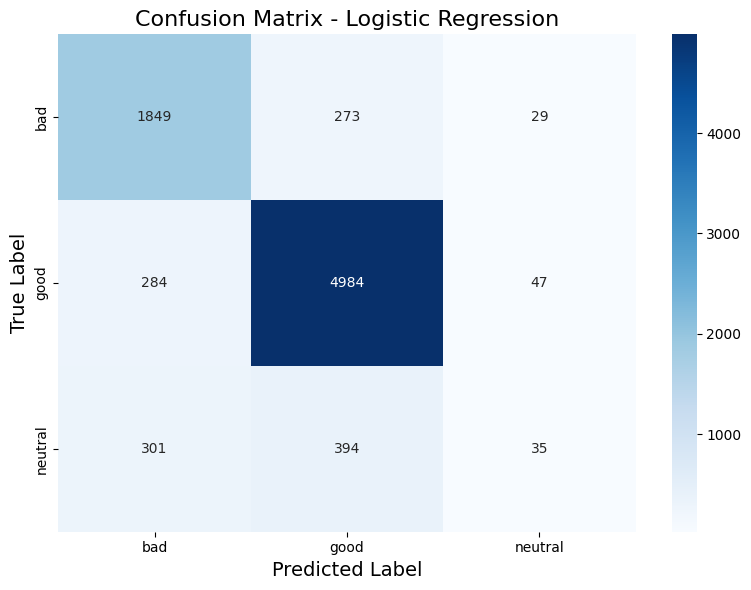

In [34]:
# Create and display confusion matrix

# On calcule la matrice de confusion
from sklearn.metrics import confusion_matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lr_classifier.classes_, 
            yticklabels=lr_classifier.classes_)
plt.title('Confusion Matrix - Logistic Regression', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show();


In [35]:
# Get feature importance from Logistic Regression model
feature_importance = pd.DataFrame({
    'feature': tfidf_vectorizer.get_feature_names_out(),
    'importance': lr_classifier.coef_.mean(axis=0)
})

# Sort by absolute importance
feature_importance['abs_importance'] = abs(feature_importance['importance'])
feature_importance = feature_importance.sort_values('abs_importance', ascending=False)


In [36]:
# Display most important positive and negative words
print("Top 10 words associated with positive sentiment:")
positive_features = feature_importance.sort_values('importance', ascending=False).head(10)
print(positive_features[['feature', 'importance']])

print("\nTop 10 words associated with negative sentiment:")
negative_features = feature_importance.sort_values('importance', ascending=True).head(10)
print(negative_features[['feature', 'importance']])


Top 10 words associated with positive sentiment:
       feature    importance
4329       tim  1.221245e-14
79        ador  8.696747e-15
2282      lind  7.197946e-15
3756     receb  6.605827e-15
3442    produt  6.161738e-15
518      bonit  5.828671e-15
1613  excelent  5.292063e-15
3673       rap  5.181041e-15
1335  eficient  5.130156e-15
4082      send  4.783211e-15

Top 10 words associated with negative sentiment:
       feature    importance
503        bom -1.199041e-14
187        ame -5.902686e-15
4763      venc -5.421589e-15
4588       tud -5.338322e-15
2874   orienta -4.958996e-15
3834  reembols -4.533411e-15
4817      vier -4.329870e-15
4559      troc -4.255855e-15
4692    utiliz -4.209596e-15
3499    proteg -4.181840e-15


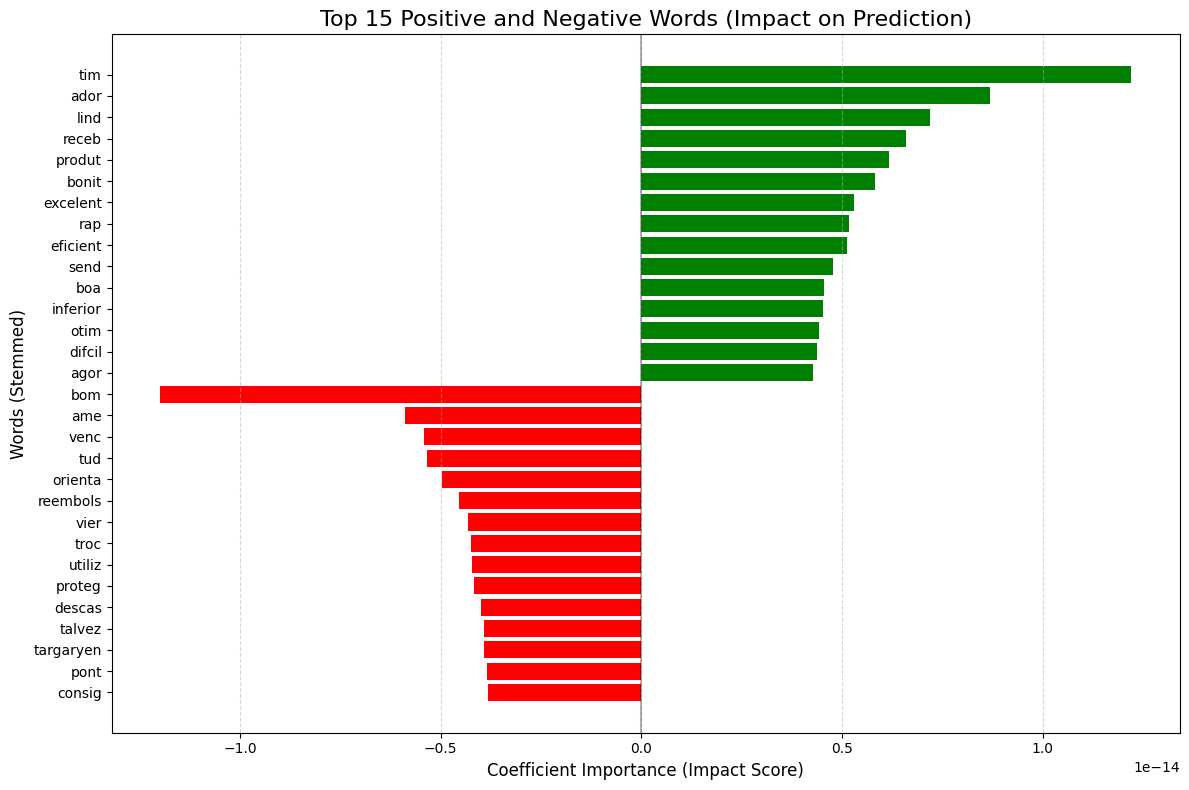

In [38]:
# Visualize top features
# 1. On crée le dataframe des top features à partir de ce qu'on a calculé avant
positive_features = feature_importance.sort_values('importance', ascending=False).head(15)
negative_features = feature_importance.sort_values('importance', ascending=True).head(15)
top_features = pd.concat([positive_features, negative_features])

# 2. On définit les couleurs (Vert pour positif, Rouge pour négatif)
colors = ['green' if x > 0 else 'red' for x in top_features['importance']]

# 3. On trace le graphique
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], color=colors)

# Détails de mise en forme
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.title('Top 15 Positive and Negative Words (Impact on Prediction)', fontsize=16)
plt.xlabel('Coefficient Importance (Impact Score)', fontsize=12)
plt.ylabel('Words (Stemmed)', fontsize=12)
plt.gca().invert_yaxis() # Mots les plus positifs en haut
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


## E - Rainforest model

In [42]:
import time
from sklearn.ensemble import RandomForestClassifier

# 1. On définit l'objet (très important !)
rf_classifier = RandomForestClassifier(
    n_estimators=100, 
    max_depth=None, 
    min_samples_split=2, 
    random_state=42, 
    n_jobs=-1
)

# 2. On lance le chrono
start_time = time.time()

# 3. On entraîne sur les données TF-IDF
rf_classifier.fit(X_train_tfidf, y_train)

# 4. On fait les prédictions
y_pred_rf = rf_classifier.predict(X_test_tfidf)

# 5. On calcule le temps
training_time = time.time() - start_time
print(f"Random Forest training: {training_time:.2f} seconds")

Random Forest training: 1.43 seconds


In [43]:
# Evaluate the model

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2f}")



Random Forest Accuracy: 0.83


In [44]:
# Display the classification report

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

         bad       0.73      0.85      0.78      2151
        good       0.88      0.93      0.90      5315
     neutral       0.25      0.02      0.04       730

    accuracy                           0.83      8196
   macro avg       0.62      0.60      0.57      8196
weighted avg       0.78      0.83      0.80      8196



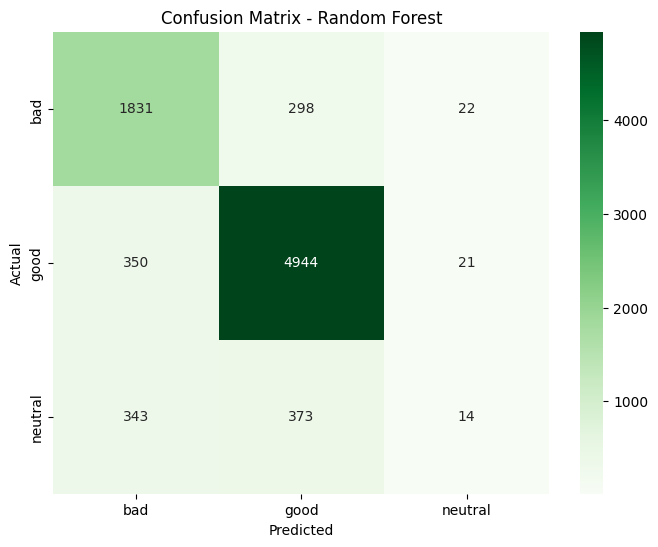

In [45]:
# Create and display the confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [46]:
# get the feature importance of the Random Forest model

importances = rf_classifier.feature_importances_
feature_names = tfidf_vectorizer.get_feature_names_out()

rf_feature_importance = pd.DataFrame({'feature': feature_names, 'importance': importances})
rf_feature_importance = rf_feature_importance.sort_values('importance', ascending=False).head(20)


/var/folders/1h/pcyg9d5941g2br5swywdh2g40000gn/T/ipykernel_11036/1830083651.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_feature_importance, x='importance', y='feature', palette='viridis')


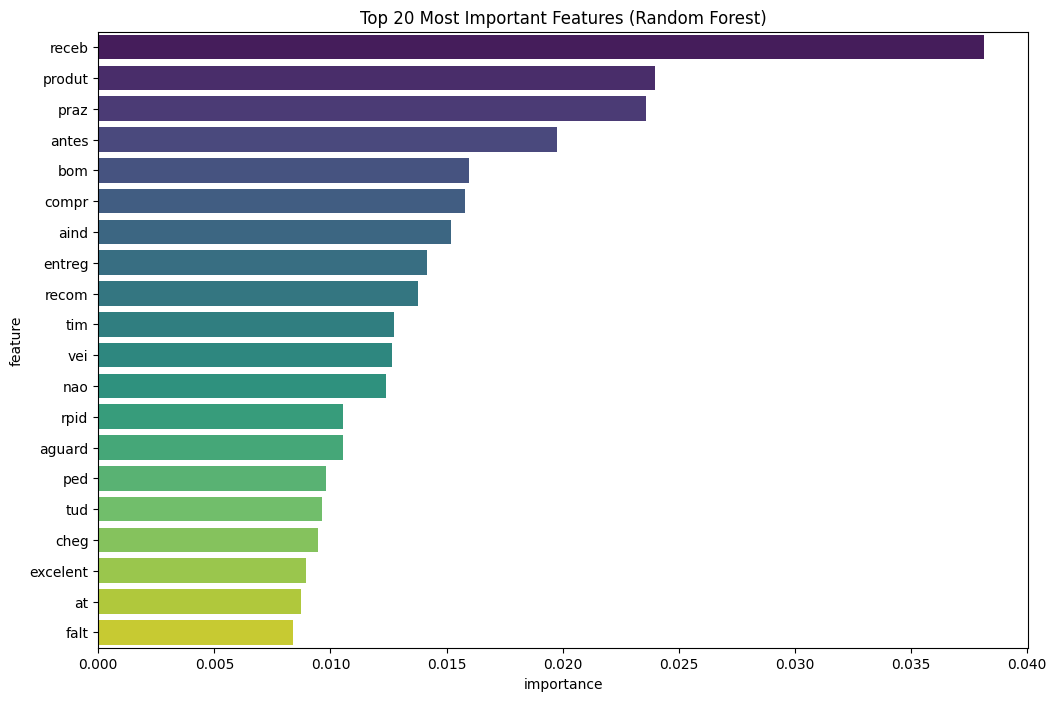

In [47]:
# Visualize the most important features

plt.figure(figsize=(12, 8))
sns.barplot(data=rf_feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Top 20 Most Important Features (Random Forest)')
plt.show()


## F - Model comparison

/var/folders/1h/pcyg9d5941g2br5swywdh2g40000gn/T/ipykernel_11036/924116523.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='magma')


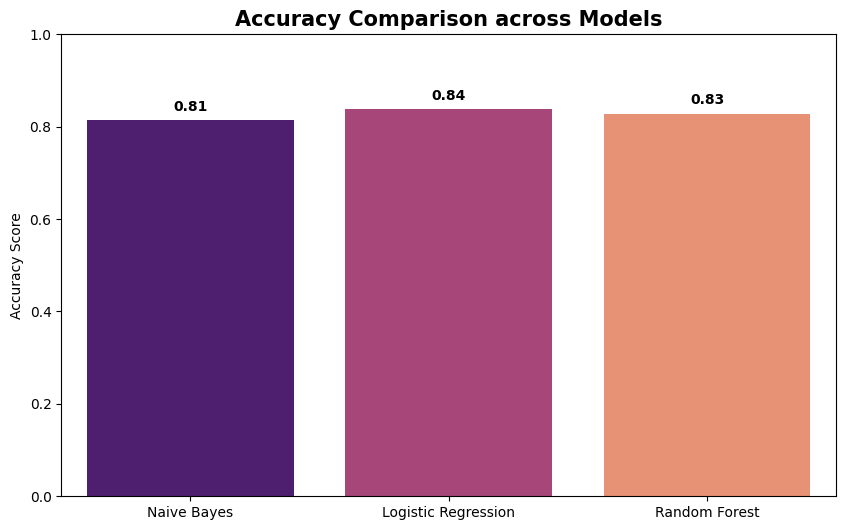

In [51]:

# Compare the performances of the 2 models
# 1. On récupère les scores de précision (accuracy) pour chaque modèle
# On utilise score() ou accuracy_score() sur nos modèles déjà entraînés
acc_nb = nb_classifier.score(X_test_counts, y_test)
acc_lr = lr_classifier.score(X_test_tfidf, y_test)
acc_rf = rf_classifier.score(X_test_tfidf, y_test)

# 2. On prépare les données pour le graphique
models = ['Naive Bayes', 'Logistic Regression', 'Random Forest']
accuracies = [acc_nb, acc_lr, acc_rf]

# 3. Affichage du graphique
plt.figure(figsize=(10, 6))
sns.barplot(x=models, y=accuracies, palette='magma')
plt.title('Accuracy Comparison across Models', fontsize=15, fontweight='bold')
plt.ylim(0, 1)

# Ajout des valeurs au-dessus des barres
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.ylabel('Accuracy Score')
plt.show()

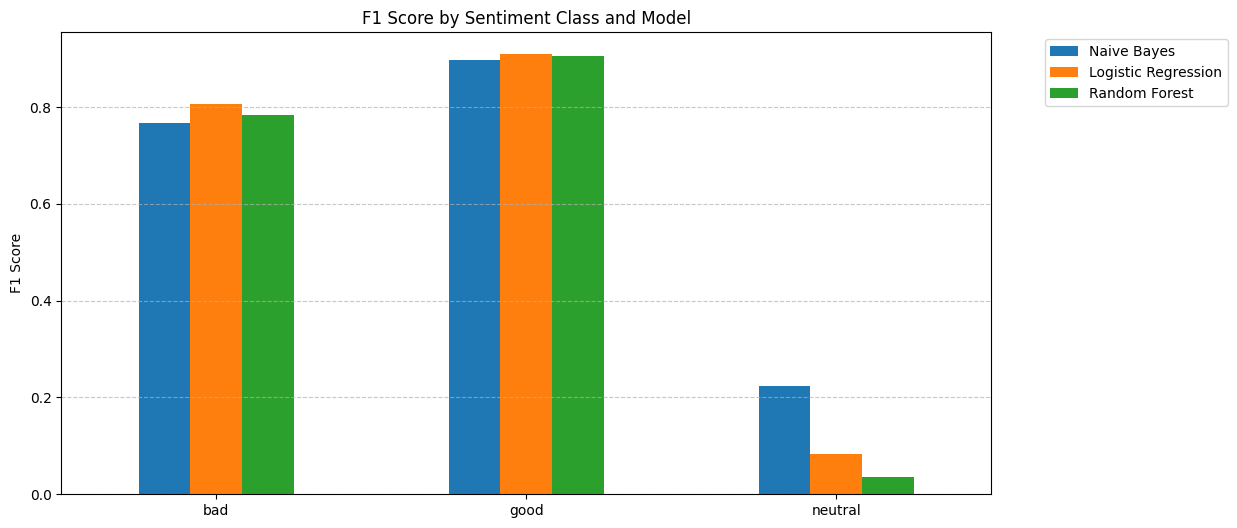

In [52]:
from sklearn.metrics import f1_score

# On calcule les F1-scores pour chaque modèle (average='weighted' car classes déséquilibrées)
f1_nb = f1_score(y_test, y_pred, average=None)
f1_lr = f1_score(y_test, y_pred_lr, average=None)
f1_rf = f1_score(y_test, y_pred_rf, average=None)

# Création du dataframe pour la visualisation (le code est déjà partiellement dans ton image)
f1_df = pd.DataFrame({
    'Naive Bayes': f1_nb,
    'Logistic Regression': f1_lr,
    'Random Forest': f1_rf
}, index=rf_classifier.classes_)

# Visualisation des F1 scores par classe
f1_df.plot(kind='bar', figsize=(12, 6))
plt.title('F1 Score by Sentiment Class and Model')
plt.ylabel('F1 Score')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## G - Example use case: predicting new comments

In [53]:
# Create a function to predict sentiment for new reviews
def predict_sentiment(review_text, vectorizer, model):
    # Preprocess the review
    processed_review = preprocess_text(review_text)
    # Vectorize the review
    review_vector = vectorizer.transform([processed_review])
    # Predict the sentiment
    sentiment = model.predict(review_vector)[0]
    # Get prediction probabilities
    proba = model.predict_proba(review_vector)[0]
    # Return the sentiment and confidence
    return sentiment, proba


In [56]:
# Example reviews to test
example_reviews = [
    "O produto é excelente, superou minhas expectativas!",  # Positive
    "Entrega foi feita no prazo, mas o produto não é tão bom quanto esperava.",  # Neutral
    "Péssimo produto, chegou com defeito e o atendimento ao cliente foi horrível."  # Negative
]

# Predict sentiment for example reviews
print("Predicting sentiment for example reviews:")
for i, review in enumerate(example_reviews):
    sentiment, proba = predict_sentiment(review, tfidf_vectorizer, lr_classifier)
    print(f"\nExample {i+1}: {review}")
    print(f"Predicted sentiment: {sentiment}")
    print(f"Confidence: {max(proba):.2f}")
    print(f"Probabilities: {dict(zip(lr_classifier.classes_, proba))}")
    

Predicting sentiment for example reviews:

Example 1: O produto é excelente, superou minhas expectativas!
Predicted sentiment: good
Confidence: 0.99
Probabilities: {'bad': 0.005297078338062406, 'good': 0.9893769547075499, 'neutral': 0.005325966954387666}

Example 2: Entrega foi feita no prazo, mas o produto não é tão bom quanto esperava.
Predicted sentiment: good
Confidence: 0.47
Probabilities: {'bad': 0.19131008789723203, 'good': 0.47483110927621086, 'neutral': 0.33385880282655706}

Example 3: Péssimo produto, chegou com defeito e o atendimento ao cliente foi horrível.
Predicted sentiment: bad
Confidence: 0.98
Probabilities: {'bad': 0.9826662197968137, 'good': 0.009086132135471386, 'neutral': 0.00824764806771498}


# II - Delivery prediction (bonus)

## A - Data preparation

In [61]:
# We'll use the merged dataframe from previous parts
# If not already done, we need to merge the necessary dataframes
# On charge les datasets nécessaires
df_orders = pd.read_csv(raw_path + 'olist_orders_dataset.csv')
df_customers = pd.read_csv(raw_path + 'olist_customers_dataset.csv')
df_order_items = pd.read_csv(raw_path + 'olist_order_items_dataset.csv')
df_products = pd.read_csv(raw_path + 'olist_products_dataset.csv')
df_sellers = pd.read_csv(raw_path + 'olist_sellers_dataset.csv') # <-- AJOUTÉ

# Merge des datasets
df = df_orders.merge(df_customers, on='customer_id')
df = df.merge(df_order_items, on='order_id')
df = df.merge(df_products, on='product_id')
df = df.merge(df_sellers, on='seller_id') # <-- AJOUTÉ

# Convert date columns to datetime
date_columns = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col])

# On crée le dataframe pour la livraison
delivery_df = df.dropna(subset=['order_delivered_customer_date'])
delivery_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752,mogi das cruzes,SP


In [58]:
# Convert date columns to datetime
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

for col in date_columns:
    df[col] = pd.to_datetime(df[col])


# Calculate delivery time in days
df['actual_delivery_time'] = (df['order_delivered_customer_date'] - 
                             df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# Calculate if the delivery was delayed (1) or not (0)
df['estimated_delivery_time'] = (df['order_estimated_delivery_date'] - 
                                df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
df['is_delayed'] = (df['actual_delivery_time'] > df['estimated_delivery_time']).astype(int)

# Calculate time to carrier in days
df['time_to_carrier'] = (df['order_delivered_carrier_date'] - 
                        df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# Filter out rows with missing delivery dates (canceled orders, etc.)
delivery_df = df.dropna(subset=['order_delivered_customer_date', 'order_delivered_carrier_date'])

delivery_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,actual_delivery_time,estimated_delivery_time,is_delayed,time_to_carrier
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,268.0,4.0,500.0,19.0,8.0,13.0,8.436574,15.544063,0,2.373924
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,178.0,1.0,400.0,19.0,13.0,19.0,13.782037,19.137766,0,1.742627
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,232.0,1.0,420.0,24.0,19.0,21.0,9.394213,26.639711,0,0.216100
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,468.0,3.0,450.0,30.0,10.0,20.0,13.208750,26.188819,0,3.758252
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,316.0,4.0,250.0,51.0,15.0,15.0,2.873877,12.112049,0,0.936053


/var/folders/1h/pcyg9d5941g2br5swywdh2g40000gn/T/ipykernel_11036/1813984735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_delayed', data=delivery_df, palette='viridis')


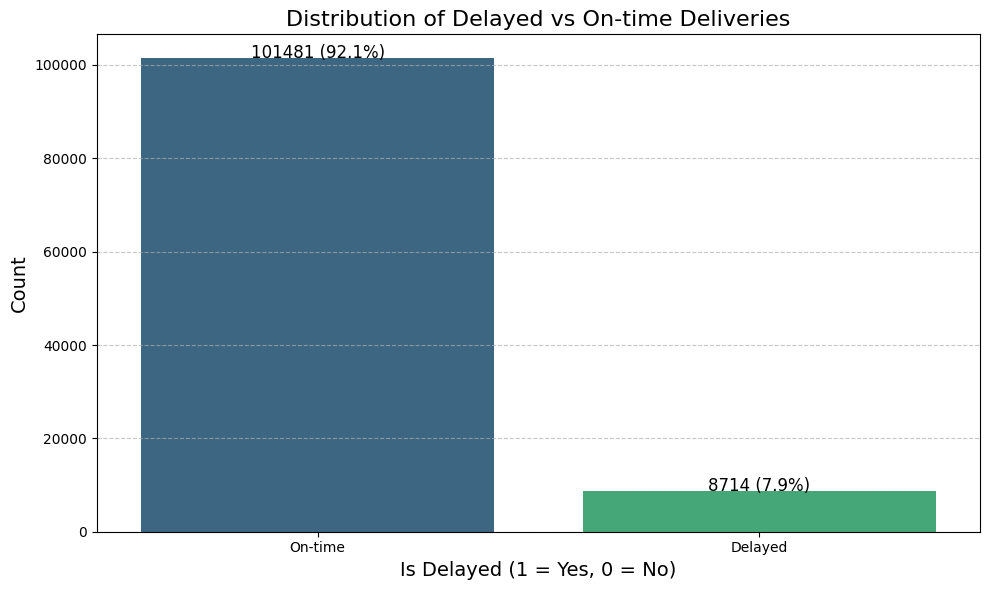

In [59]:
# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='is_delayed', data=delivery_df, palette='viridis')
plt.title('Distribution of Delayed vs On-time Deliveries', fontsize=16)
plt.xlabel('Is Delayed (1 = Yes, 0 = No)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks([0, 1], ['On-time', 'Delayed'])
for i, count in enumerate(delivery_df['is_delayed'].value_counts()):
    plt.text(i, count + 100, f"{count} ({count/len(delivery_df):.1%})", 
             ha='center', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## B - Feature Engineering

In [62]:

model_df = delivery_df.copy()

# Extract temporal features
model_df['purchase_hour'] = model_df['order_purchase_timestamp'].dt.hour
model_df['purchase_day'] = model_df['order_purchase_timestamp'].dt.day
model_df['purchase_month'] = model_df['order_purchase_timestamp'].dt.month
model_df['purchase_year'] = model_df['order_purchase_timestamp'].dt.year
model_df['purchase_dayofweek'] = model_df['order_purchase_timestamp'].dt.dayofweek
model_df['purchase_weekend'] = (model_df['purchase_dayofweek'] >= 5).astype(int)

# Calculate distance between customer and seller (using zip code prefix as a proxy)
model_df['zip_distance'] = abs(model_df['customer_zip_code_prefix'] - model_df['seller_zip_code_prefix'])

# Calculate price per weight
model_df['price_per_weight'] = model_df['price'] / model_df['product_weight_g'].replace(0, 0.1)

# Create product volume feature
model_df['product_volume'] = (model_df['product_length_cm'] * 
                             model_df['product_height_cm'] * 
                             model_df['product_width_cm'])

# Handle infinite values
model_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Display the first few rows of the engineered features
print("Sample of engineered features:")
model_df[['purchase_hour', 'purchase_day', 'purchase_month', 'purchase_year', 
                'purchase_dayofweek', 'purchase_weekend', 'zip_distance', 
                'price_per_weight', 'product_volume']].head()

Sample of engineered features:


,purchase_hour,purchase_day,purchase_month,purchase_year,purchase_dayofweek,purchase_weekend,zip_distance,price_per_weight,product_volume
0,10,2,10,2017,0,0,6201,0.059980,1976.0
1,20,24,7,2018,1,0,16243,0.296750,4693.0
2,8,8,8,2018,2,0,60425,0.380714,9576.0
3,19,18,11,2017,5,1,27454,0.100000,6000.0
4,21,13,2,2018,1,0,443,0.079600,11475.0


## C - Exploratory Data Analysis for Feature Selection

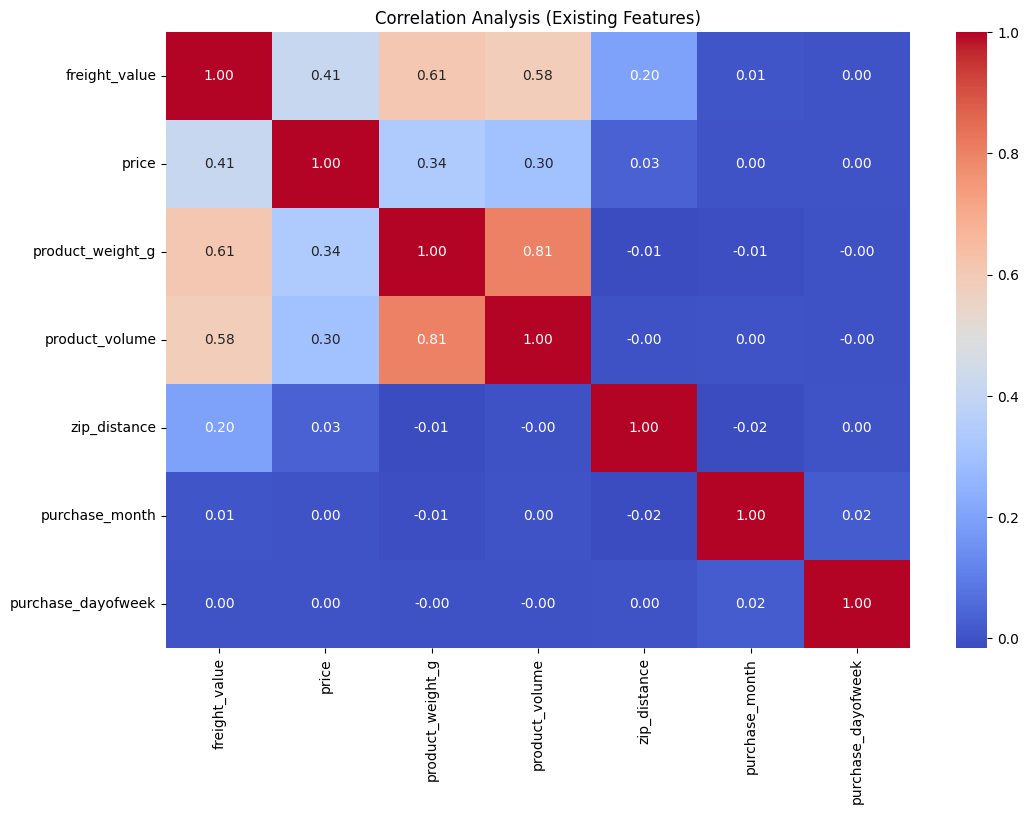

In [65]:
# Analyze correlation between features and delivery time with a correlation matrix

# 1. On liste toutes les colonnes qu'on aimerait analyser
potential_features = [
    'freight_value', 'price', 'product_weight_g', 
    'product_volume', 'zip_distance', 'purchase_month', 
    'purchase_dayofweek', 'actual_delivery_time'
]

# 2. On ne garde QUE celles qui sont vraiment présentes dans le tableau
# (Cela évite l'erreur KeyError si une colonne manque)
existing_features = [f for f in potential_features if f in model_df.columns]

# 3. On calcule la matrice sur ces colonnes existantes
plt.figure(figsize=(12, 8))
correlation_matrix = model_df[existing_features].corr()

# 4. Affichage
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Analysis (Existing Features)')
plt.show()

In [71]:
# 1. Vérification des colonnes disponibles 
print("Colonnes dans model_df :", model_df.columns.tolist())

# 2. On définit nos listes
numeric_cols = ['freight_value', 'price', 'product_weight_g', 'product_volume', 'zip_distance']
cat_cols = ['customer_state', 'seller_state', 'product_category_name']

existing_numeric = [c for c in numeric_cols if c in model_df.columns]
target_col = 'actual_delivery_time' 

# 4. Matrice de corrélation
if target_col in model_df.columns:
    plt.figure(figsize=(10, 8))
    corr = model_df[existing_numeric + [target_col]].corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Analyse des corrélations')
    plt.show()
else:
    print(f"Attention : La colonne {target_col} est absente !")

# 5. Graphiques en barres
for feature in cat_cols:
    if feature in model_df.columns and target_col in model_df.columns:
        plt.figure(figsize=(12, 5))
        model_df.groupby(feature)[target_col].mean().sort_values(ascending=False).plot(kind='bar')
        plt.title(f'Délai moyen par {feature}')
        plt.ylabel('Jours')
        plt.show()

Colonnes dans model_df : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'purchase_hour', 'purchase_day', 'purchase_month', 'purchase_year', 'purchase_dayofweek', 'purchase_weekend', 'zip_distance', 'price_per_weight', 'product_volume']
Attention : La colonne actual_delivery_time est absente !


## D - Feature Selection

In [72]:
# Select features based on correlation analysis and domain knowledge
selected_numeric_features = ['freight_value', 'price', 'product_weight_g', 
                            'product_volume', 'zip_distance', 'time_to_carrier',
                            'purchase_month', 'purchase_dayofweek']


In [77]:
# 1. Calcul du délai de livraison réel 
# On calcule la différence entre la livraison et l'achat en jours
model_df['actual_delivery_time'] = (model_df['order_delivered_customer_date'] - 
                                    model_df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# 2. On s'assure que les autres colonnes calculées sont là
model_df['product_volume'] = model_df['product_length_cm'] * model_df['product_height_cm'] * model_df['product_width_cm']
model_df['zip_distance'] = abs(model_df['customer_zip_code_prefix'] - model_df['seller_zip_code_prefix'])

# 3. On définit nos colonnes pour le modèle
selected_numeric_features = ['freight_value', 'price', 'product_weight_g', 'product_volume', 'zip_distance']
selected_categorical_features = ['customer_state', 'seller_state']

# 4. Nettoyage des NaNs 
model_df = model_df.dropna(subset=selected_numeric_features + ['actual_delivery_time'])

# 5. Préparation X et y
X_numeric = model_df[selected_numeric_features]
X_categorical = pd.get_dummies(model_df[selected_categorical_features], drop_first=True)
X_combined = pd.concat([X_numeric, X_categorical], axis=1)
y_regression = model_df['actual_delivery_time']

# 6. Split Train/Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X_combined, y_regression, test_size=0.2, random_state=42
)

print(f"Taille du Train : {X_train.shape[0]} lignes")

Taille du Train : 88142 lignes


/var/folders/1h/pcyg9d5941g2br5swywdh2g40000gn/T/ipykernel_11036/2996756869.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df['actual_delivery_time'] = (model_df['order_delivered_customer_date'] -
/var/folders/1h/pcyg9d5941g2br5swywdh2g40000gn/T/ipykernel_11036/2996756869.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  model_df['product_volume'] = model_df['product_length_cm'] * model_df['product_height_cm'] * model_df['product_width_cm']
/var/folders/1h/pcyg9d5941g2br5swywdh2g40000gn/T/ipyke

## E - Building the Regression Model (Predicting Delivery Time)

In [78]:
# Define preprocessing for numeric features

from sklearn.preprocessing import StandardScaler

# On définit le scaler pour les colonnes numériques
scaler = StandardScaler()


In [79]:
# Create a Linear Regression Pipeline

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Create a Linear Regression Pipeline
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

# Train Linear Regression
lr_pipeline.fit(X_train, y_reg_train)


Pipeline(steps=[('scaler', StandardScaler()), ('lr', LinearRegression())])

In [81]:
# 1. Make predictions based on your linear regression
y_reg_pred = lr_pipeline.predict(X_test)

# 2. Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_lr = mean_absolute_error(y_reg_test, y_reg_pred)
rmse_lr = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2_lr = r2_score(y_reg_test, y_reg_pred)



the R² should be about 0.40, which is not a good number. Can you do better with a Random Forest model, or any other model? 

Objective is to get a R² > 0.45!

## F - Building a Random Forest model

In [82]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score # <-- AJOUTÉ ICI

# 1. On crée et entraîne le modèle
# n_estimators=100 : 100 arbres travaillent ensemble pour prédire
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_reg_train)

# 2. Prédictions
y_pred_rf = rf_reg.predict(X_test)

# 3. Évaluation
mae_rf = mean_absolute_error(y_reg_test, y_pred_rf)
r2_rf = r2_score(y_reg_test, y_pred_rf)

print(f"Random Forest - MAE: {mae_rf:.2f} days")
print(f"Random Forest - R2: {r2_rf:.2f}")

Random Forest - MAE: 5.02 days
Random Forest - R2: 0.27


### G - Building a K-Nearest Neighbors model

In [83]:
from sklearn.neighbors import KNeighborsRegressor

# On utilise souvent 5 ou 7 voisins (k)
knn_reg = KNeighborsRegressor(n_neighbors=7)
knn_reg.fit(X_train, y_reg_train)

# Prédictions
y_pred_knn = knn_reg.predict(X_test)

# Évaluation
mae_knn = mean_absolute_error(y_reg_test, y_pred_knn)
r2_knn = r2_score(y_reg_test, y_pred_knn)

print(f"KNN - MAE: {mae_knn:.2f} days")
print(f"KNN - R2: {r2_knn:.2f}")

KNN - MAE: 5.86 days
KNN - R2: 0.07
